# AG-HYPOPT · Trial 05

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Four trials done, all at `sigma_weight` ~0.41-0.51, all worse than the frozen KDE control (0.080328):
**trial_01** `w1_2d` **0.0895**, **trial_04** `w1_fwhm` **0.0908** (statistically tied with trial_01, so
the sigma channel does not matter for W1), **trial_02** `energy_2d` **0.0996**, **trial_03** `mmd_2d`
**0.1833** (much the worst, mu low everywhere). No divergences. Ranked: `kde` (ref 0.0803) < `w1_2d`
(0.0895) ~ `w1_fwhm` (0.0908) < `energy_2d` (0.0996) < `mmd_2d` (0.1833). Only `cvm_fwhm` and the
`kde` control itself remain untested; phase still `uniform` (4/5).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_05'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (4/5 trials)
ID |     ei | params
 1 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.8079407897364937}
 2 |      - | {"loss_family": "w1_fwhm", "sigma_weight": 0.515325561042142}
 3 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.053930702381656426}
 4 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.38336888078551823}
 5 |      - | {"loss_family": "mmd_2d", "sigma_weight": 0.045275193902445166}
 6 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.04875771072716806}
 7 |      - | {"loss_family": "kde", "sigma_weight": 0.6523691115879877}
 8 |      - | {"loss_family": "cvm_fwhm", "sigma_weight": 0.23451020166982395}
 9 |      - | {"loss_family": "w1_2d", "sigma_weight": 0.9741861932592554}
10 |      - | {"loss_family": "energy_2d", "sigma_weight": 0.8976776081085488}


## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Only `cvm_fwhm` and `kde` lack a trial. This is the last `uniform`-phase step before exploitation begins,
so it should close the family-coverage gap. `kde` would just re-anchor the known control value (0.0803)
and is better used later as a verification; `cvm_fwhm` is the one genuinely untested form.

Scanning the table: candidates 1 and 2 are more `w1_fwhm` (have a point); 3 and 5 `mmd_2d` (worst, low
value); 4 and 9 `w1_2d` (have a point); 6 and 10 `energy_2d` (have a point); 7 is `kde` (control).
Candidate 8 is the only `cvm_fwhm` in the batch (sw 0.2345). Like `w1_fwhm`, this FWHM-only family makes
`sigma_weight` inert, so its exact value is immaterial - the trial completes the loss-form matrix.

I choose candidate 8.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8             # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'loss_family': 'cvm_fwhm', 'sigma_weight': 0.23451020166982395}
Running  1nW Trans05 ... 

μ 9.39 -> 5.44 | γ 8.5 -> 4.21 | NLL 158.45


Running  1nW Trans20 ... 

μ 17.32 -> 22.72 | γ 8.5 -> 5.90 | NLL 0.88


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 62.03 | γ 14.1 -> 13.95 | NLL 0.48


Running 3nW Trans100 ... 

μ 175.71 -> 97.20 | γ 14.1 -> 13.52 | NLL 0.44



Total: 7.7 min


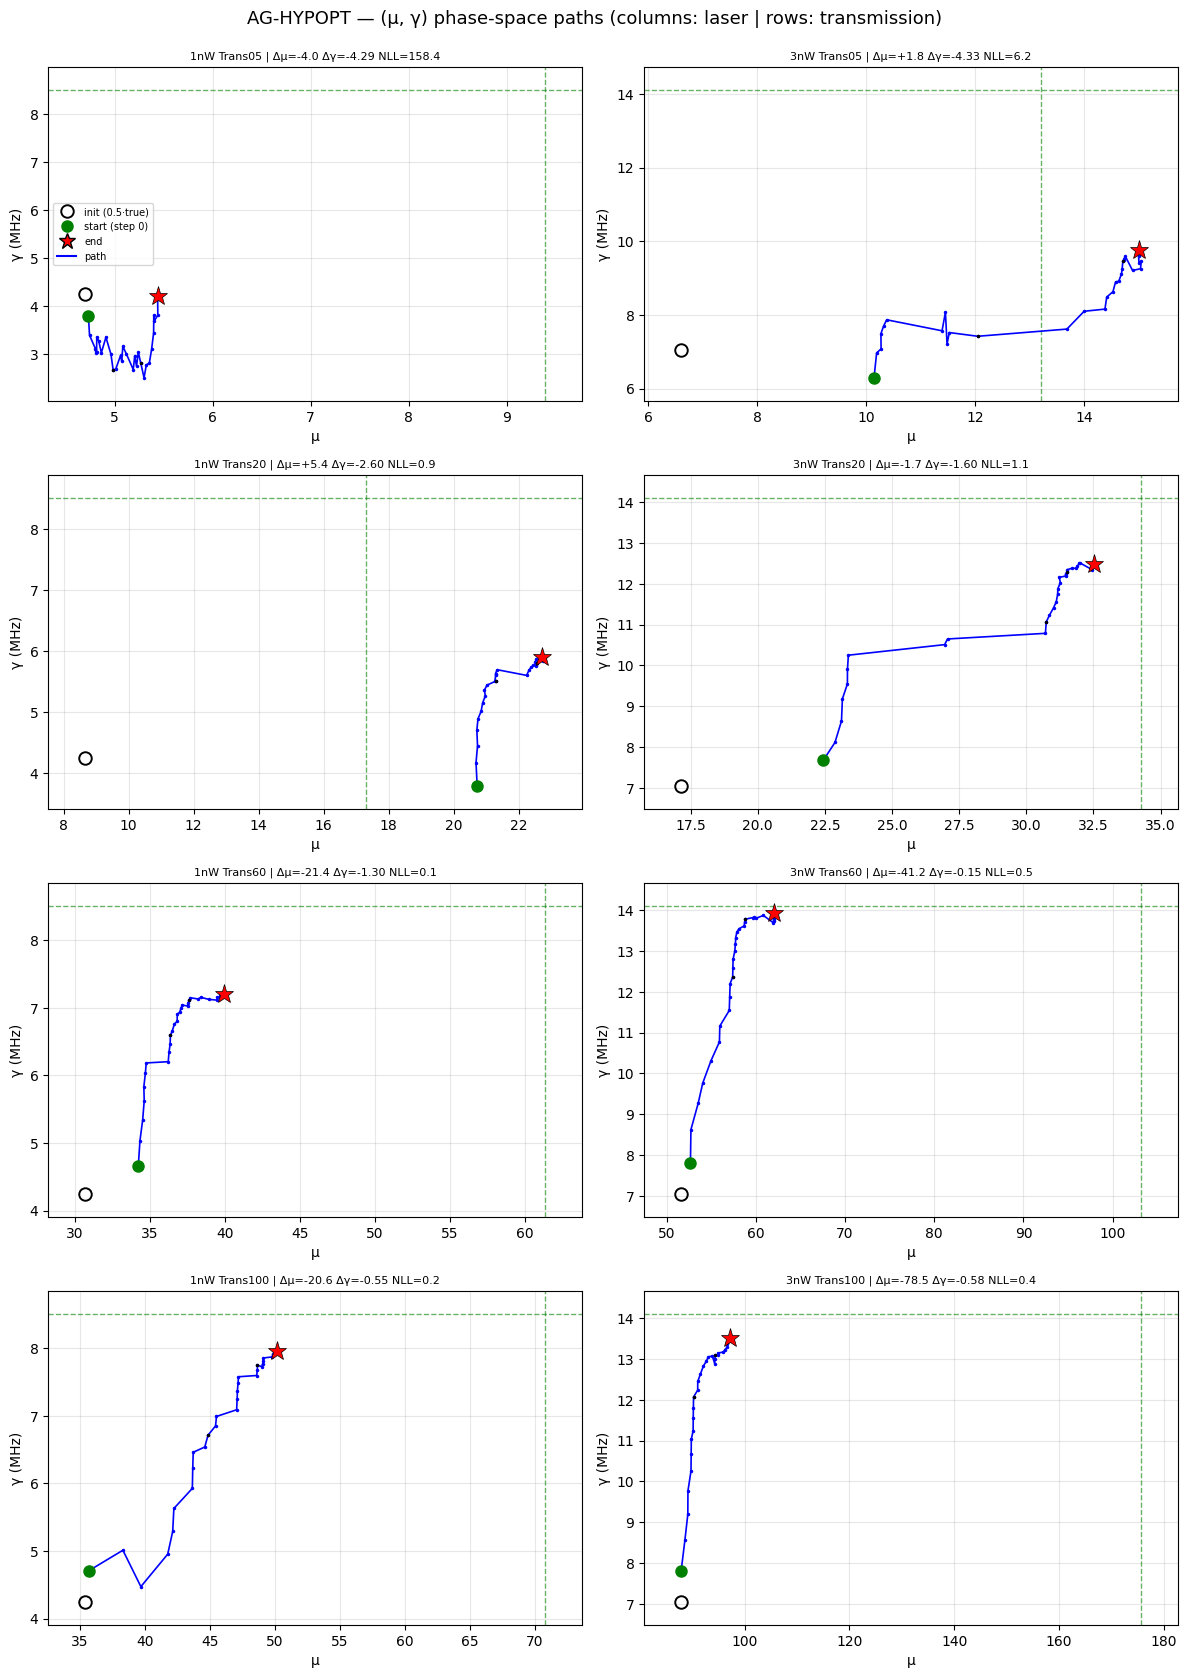

trial finished in 7.7 min
objective = 0.0777 ± 0.0202
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    5.44   -42.1 |     8.50    4.21   -50.4
1nW Trans20       17.32   22.72   +31.2 |     8.50    5.90   -30.5
1nW Trans60       61.37   39.94   -34.9 |     8.50    7.20   -15.3
1nW Trans100       70.82   50.18   -29.1 |     8.50    7.95    -6.4
3nW Trans05       13.20   15.01   +13.7 |    14.10    9.77   -30.7
3nW Trans20       34.28   32.53    -5.1 |    14.10   12.50   -11.4
3nW Trans60      103.20   62.03   -39.9 |    14.10   13.95    -1.1
3nW Trans100      175.71   97.20   -44.7 |    14.10   13.52    -4.1

weighted objective (T-graded, cap=1.0) = 0.0777 | diverged cells: 0
μ: RMSE 33.157 (rel 32.8%, bias -20.030) | γ: RMSE 2.468 (rel 24.6%, bias -1.923)


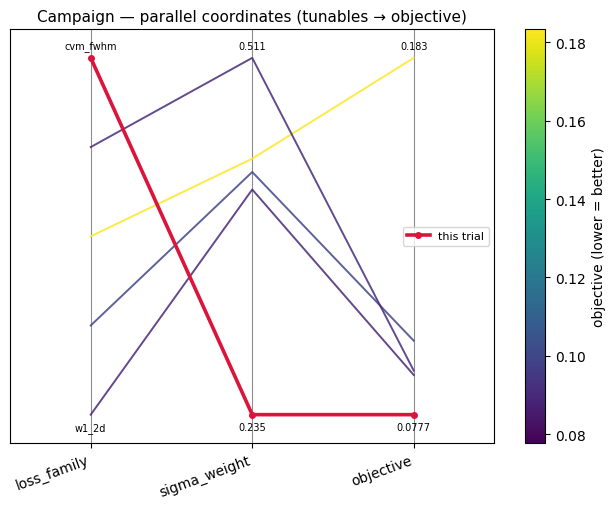

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

**Facts.** Chosen config `{loss_family: 'cvm_fwhm', sigma_weight: 0.2345}` (candidate 8). Trial
time 7.7 min, objective **0.0777 +/- 0.0202**, **0 diverged cells**. This is a **new campaign best**:
it beats the frozen KDE control (0.080328) by ~0.0026 (though the two are within combined uncertainty),
and is clearly better than every other alternative tested (`w1_2d` 0.0895, `w1_fwhm` 0.0908,
`energy_2d` 0.0996, `mmd_2d` 0.1833). As for `w1_fwhm`, the FWHM-only form makes `sigma_weight` inert,
so this is effectively `cvm_fwhm` plain. This trial also completes the family matrix - all six families
now have at least one point.

**Per-cell behaviour.** The improvement is spread over all cells, and the gamma channel is visibly
healthier than in any earlier trial:

- 1nW Trans05: mu -42.1 %, gamma 8.5 -> 4.21 (**-50.4 %**, vs -61 % / -67 % / -50 % / -67 % in
  trials 01-04) - the best low-count gamma yet.
- 1nW Trans20: mu +31.2 % (mildest overshoot yet, vs +66/+55/+98/+51 %), gamma -30.5 %.
- 1nW Trans60 / Trans100: mu -34.9 % / -29.1 %, gamma -15.3 % / -6.4 %.
- 3nW Trans05 / Trans20: mu +13.7 % / -5.1 %, gamma -30.7 % / -11.4 %.
- 3nW Trans60 / Trans100: mu -39.9 % / -44.7 %, gamma -1.1 % / -4.1 %.

mu is still low at high T (~-30 to -45 %), but gamma is now within ~1-6 % at high T and much improved
in the low-count cells.

**Aggregates.** mu: RMSE 33.16 (rel 32.8 %), bias -20.03; gamma: RMSE 2.47 (rel 24.6 %), bias -1.92.
The gamma figures are the **best of all five trials** (trial_01: 2.64 / 27.1 %; trial_02: 3.35 / 32.6 %;
trial_03: 3.55 / 33.3 %; trial_04: 2.88 / 29.5 %), while mu remains pinned near the same level as the
other S-D families (rel ~33-38 %). So the objective gain here is essentially a **gamma-channel gain**.

**Summary:** `cvm_fwhm` (sw 0.2345) reaches objective 0.0777, a new campaign best that edges past the
KDE control (0.0803), driven by the best gamma recovery of any trial, with mu still low at high T and
no divergences.
**Key insight:** A FWHM-only Cramer-von Mises loss currently beats the KDE control, and the gain comes
from the gamma channel (best gamma RMSE/bias of the campaign), not from mu.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: the mu channel is still the residual wall (low at high T across every family); worth a
validation run on the 6 held-out experiments before over-reading a 0.0026 margin over the control.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'cvm_fwhm (sigma_weight 0.2345) reaches objective 0.0777, a new campaign best that edges past the KDE control (0.0803), driven by the best gamma recovery of any trial.'      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = 'A FWHM-only Cramer-von Mises loss currently beats the KDE control, with the gain coming from the gamma channel rather than mu, which stays low at high T.'  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_05 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_06.ipynb. Open it and follow its cells from the top.
